# BNOT quickstart (Colab)

This notebook bootstraps a Colab runtime, clones `BNOT_new` if needed, builds `ibnot_new_cli` inside Colab if needed, and runs it through the Python wrapper.

Run the notebook from top to bottom. The first code cell is designed to be idempotent inside the same Colab runtime: it reuses the installed tools, cloned repo, Conda environment, and compiled binary whenever they already exist.

## 1. Bootstrap the Colab runtime

This cell prepares the Colab runtime. It installs missing system tools only if needed, installs Miniforge only if needed, clones the repository only if missing, creates the repo-local Conda environment only if missing, and builds the CLI only if it has not already been built in the current runtime.

In [44]:
from pathlib import Path
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/Musialski-Research-Group/BNOT_new.git"
REPO_ROOT = Path("/content/BNOT_new")
MINIFORGE_DIR = Path("/usr/local/miniforge")
CONDA_EXE = MINIFORGE_DIR / "bin" / "conda"
ENV_PREFIX = REPO_ROOT / ".conda" / "ibnot_cli"
BUILD_DIR = REPO_ROOT / "ibnot_cli" / "build-colab"
CLI_BIN = BUILD_DIR / "ibnot_new_cli"

needed_tools = []
if shutil.which("gs") is None:
    needed_tools.append("ghostscript")
if shutil.which("git") is None:
    needed_tools.append("git")
if shutil.which("wget") is None:
    needed_tools.append("wget")

if needed_tools:
    subprocess.run(["apt-get", "update"], check=True)
    subprocess.run(["apt-get", "install", "-y", *needed_tools], check=True)
    print(f"Installed system packages: {needed_tools}")
else:
    print("System tools already present; skipping apt install.")

if not CONDA_EXE.exists():
    installer = Path("/tmp/Miniforge3.sh")
    subprocess.run([
        "wget",
        "-O",
        str(installer),
        "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh",
    ], check=True)
    subprocess.run(["bash", str(installer), "-b", "-p", str(MINIFORGE_DIR)], check=True)

if not REPO_ROOT.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
    print(f"Cloned repo into {REPO_ROOT}")
else:
    print(f"Reusing existing clone at {REPO_ROOT}")

env = os.environ.copy()
env["CONDA_EXE"] = str(CONDA_EXE)
if not (ENV_PREFIX / "conda-meta").exists():
    subprocess.run(["bash", "./setup_env.sh"], cwd=REPO_ROOT / "ibnot_cli", env=env, check=True)
    print(f"Created repo-local env at {ENV_PREFIX}")
else:
    print(f"Reusing existing env at {ENV_PREFIX}")

if not CLI_BIN.exists():
    subprocess.run([
        str(CONDA_EXE),
        "run",
        "--prefix",
        str(ENV_PREFIX),
        "cmake",
        "-S",
        str(REPO_ROOT / "ibnot_cli"),
        "-B",
        str(BUILD_DIR),
        "-G",
        "Ninja",
        f"-DCMAKE_PREFIX_PATH={ENV_PREFIX}",
    ], check=True)
    subprocess.run([
        str(CONDA_EXE),
        "run",
        "--prefix",
        str(ENV_PREFIX),
        "cmake",
        "--build",
        str(BUILD_DIR),
    ], check=True)
    print(f"Built CLI at {CLI_BIN}")
else:
    print(f"Reusing existing CLI build at {CLI_BIN}")

print(f"Repo root: {REPO_ROOT}")
print(f"Conda: {CONDA_EXE}")
print(f"Build dir: {BUILD_DIR}")


System tools already present; skipping apt install.
Reusing existing clone at /content/BNOT_new
Reusing existing env at /content/BNOT_new/.conda/ibnot_cli
Reusing existing CLI build at /content/BNOT_new/ibnot_cli/build-colab/ibnot_new_cli
Repo root: /content/BNOT_new
Conda: /usr/local/miniforge/bin/conda
Build dir: /content/BNOT_new/ibnot_cli/build-colab


## 2. Load the Python wrapper and define shared notebook settings

This cell adds the cloned wrapper source to `sys.path`, imports the helper functions, points them at the Colab build of `ibnot_new_cli`, sets the common image size and point budget, and defines a small plotting helper for inspecting each result.

In [45]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REPO_ROOT = Path("/content/BNOT_new")
PYTHON_SRC = REPO_ROOT / "python" / "src"
if str(PYTHON_SRC) not in sys.path:
    sys.path.insert(0, str(PYTHON_SRC))

from ibnot_cli_wrapper import (
    make_linear_ramp,
    make_sine_landscape,
    make_uniform,
    run_case,
)

SIZE = 512
NUM_SITES = 1024
SEED = 7
OUTPUT_WIDTH = SIZE
OUTPUT_HEIGHT = SIZE
POINT_RADIUS = 0.004
DPI = 300
INVERT_DENSITY = True
OUTPUT_DIR = REPO_ROOT / "python" / "notebooks" / "_generated_colab"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CLI = REPO_ROOT / "ibnot_cli" / "build-colab" / "ibnot_new_cli"

if not CLI.exists():
    raise FileNotFoundError(f"CLI executable missing: {CLI}")
if shutil.which("gs") is None:
    raise RuntimeError("Ghostscript ('gs') is required for PNG previews.")

print(f"CLI: {CLI}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Invert density: {INVERT_DENSITY}")

def show_case(title: str, image: np.ndarray, result):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
    axes[0].set_title(f"{title} input")
    axes[0].axis("off")

    rendered = plt.imread(result.png_path)
    axes[1].imshow(rendered)
    axes[1].set_title(f"{title} output")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    print(result.stats)


CLI: /content/BNOT_new/ibnot_cli/build-colab/ibnot_new_cli
Output dir: /content/BNOT_new/python/notebooks/_generated_colab
Invert density: True


## 3. Uniform density example

Generate a constant `512x512` grayscale field with value `1.0`, run the solver at `1024` points, and display the input alongside the rendered stippling result and parsed statistics.

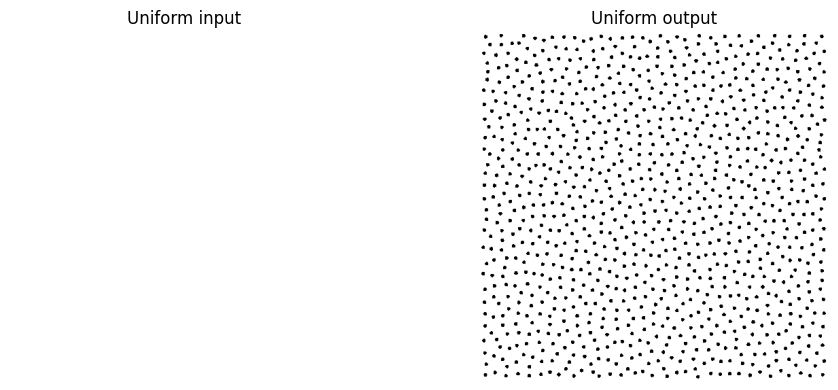

{'image_path': '/content/BNOT_new/python/notebooks/_generated_colab/uniform_512_1024_input.pgm', 'output_path': '/content/BNOT_new/python/notebooks/_generated_colab/uniform_512_1024.eps', 'stats_path': '/content/BNOT_new/python/notebooks/_generated_colab/uniform_512_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'render_width': 512, 'render_height': 512, 'point_radius': 0.004, 'visible_sites': 1024, 'iterations': 2, 'energy': -0.04438753042223681, 'mean_capacity': 0.2490234375, 'mean_abs_capacity_error': 3.689751193702807e-07, 'max_abs_capacity_error': 5.455416633040611e-05, 'rms_abs_capacity_error': 2.252168027295134e-06, 'mean_rel_capacity_error': 1.481688322490853e-06, 'max_rel_capacity_error': 0.0002190724169503367, 'rms_rel_capacity_error': 9.044000235098892e-06}


In [47]:
uniform = make_uniform(size=SIZE, value=1.0)
uniform_result = run_case(
    uniform,
    OUTPUT_DIR,
    "uniform_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    invert=False, # DO NOT INVERT FOR UNIFORM WHITE IMAGE
    dpi=DPI,
)
show_case("Uniform", uniform, uniform_result)


## 4. Left-to-right ramp example

Generate a linear ramp that is white on the left and black on the right, run the solver at the same `1024`-point budget, and compare the resulting density shift visually.

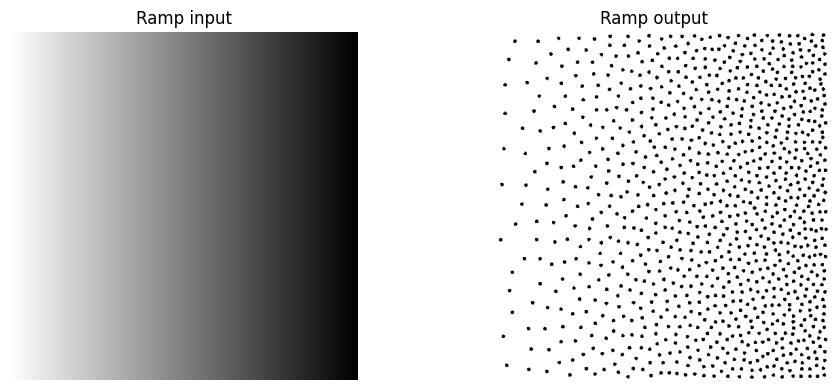

{'image_path': '/content/BNOT_new/python/notebooks/_generated_colab/ramp_512_1024_input.pgm', 'output_path': '/content/BNOT_new/python/notebooks/_generated_colab/ramp_512_1024.eps', 'stats_path': '/content/BNOT_new/python/notebooks/_generated_colab/ramp_512_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'render_width': 512, 'render_height': 512, 'point_radius': 0.004, 'visible_sites': 1024, 'iterations': 2, 'energy': -0.02174935040801814, 'mean_capacity': 0.12451171875, 'mean_abs_capacity_error': 1.502110517006557e-07, 'max_abs_capacity_error': 7.739789008531783e-06, 'rms_abs_capacity_error': 5.366435291017669e-07, 'mean_rel_capacity_error': 1.206400917188012e-06, 'max_rel_capacity_error': 6.216112897832585e-05, 'rms_rel_capacity_error': 4.309984108236936e-06}


In [51]:
ramp = make_linear_ramp(size=SIZE, left=1.0, right=0.0)
ramp_result = run_case(
    ramp,
    OUTPUT_DIR,
    "ramp_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    invert=INVERT_DENSITY,
    dpi=DPI,
)
show_case("Ramp", ramp, ramp_result)


## 5. 2D sine landscape example

Generate a normalized product-of-sines landscape, run the solver again at `1024` points, and inspect how the stipple density follows the oscillating input field.

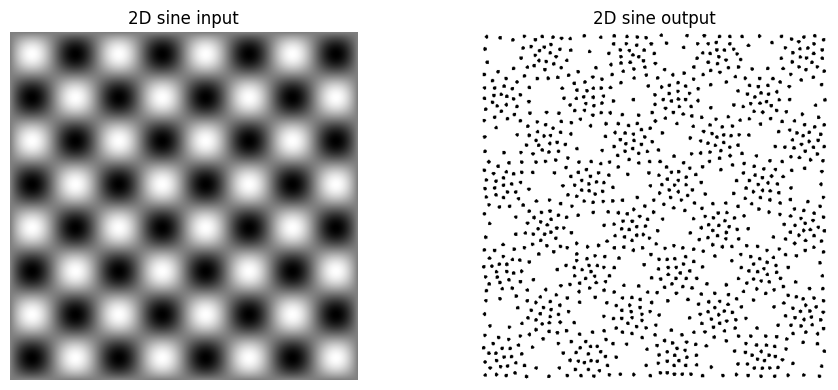

{'image_path': '/content/BNOT_new/python/notebooks/_generated_colab/sine2d_512_1024_input.pgm', 'output_path': '/content/BNOT_new/python/notebooks/_generated_colab/sine2d_512_1024.eps', 'stats_path': '/content/BNOT_new/python/notebooks/_generated_colab/sine2d_512_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'render_width': 512, 'render_height': 512, 'point_radius': 0.004, 'visible_sites': 1024, 'iterations': 3, 'energy': -0.02067785230644869, 'mean_capacity': 0.1245097443461418, 'mean_abs_capacity_error': 4.559792494110329e-08, 'max_abs_capacity_error': 1.046358634566869e-05, 'rms_abs_capacity_error': 3.792444879254508e-07, 'mean_rel_capacity_error': 3.662197298738268e-07, 'max_rel_capacity_error': 8.403829275064222e-05, 'rms_rel_capacity_error': 3.045902069087353e-06}


In [52]:
sine = make_sine_landscape(size=SIZE, fx=4, fy=4)
sine_result = run_case(
    sine,
    OUTPUT_DIR,
    "sine2d_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    invert=INVERT_DENSITY,
    dpi=DPI,
)
show_case("2D sine", sine, sine_result)


### 7. Image Url

Upload any image, convert it to grayscale with Pillow, resize it to the configured `SIZE x SIZE`, and run the same `1024`-point pipeline. The same inversion toggle used above is applied here as well.


Using existing file: cameraman.jpg


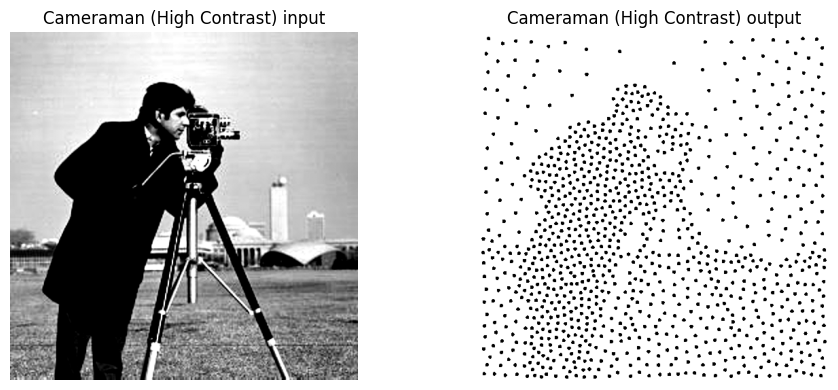

{'image_path': '/content/BNOT_new/python/notebooks/_generated_colab/cameraman_high_contrast_512_1024_input.pgm', 'output_path': '/content/BNOT_new/python/notebooks/_generated_colab/cameraman_high_contrast_512_1024.eps', 'stats_path': '/content/BNOT_new/python/notebooks/_generated_colab/cameraman_high_contrast_512_1024.txt', 'weight_solver': 'newton', 'seed': 7, 'render_width': 512, 'render_height': 512, 'point_radius': 0.004, 'visible_sites': 1024, 'iterations': 3, 'energy': -0.0193545223568566, 'mean_capacity': 0.1150890477001667, 'mean_abs_capacity_error': 4.813461510954286e-08, 'max_abs_capacity_error': 8.671907670745882e-06, 'rms_abs_capacity_error': 3.37009197293087e-07, 'mean_rel_capacity_error': 4.182380171825259e-07, 'max_rel_capacity_error': 7.534954753764394e-05, 'rms_rel_capacity_error': 2.928247335672401e-06}


In [54]:
import requests
from pathlib import Path
from PIL import Image, ImageEnhance
import numpy as np

image_url = "https://www.math.hkust.edu.hk/~masyleung/Teaching/CAS/MATLAB/image/images/cameraman.jpg"
local_filename = "cameraman.jpg"
local_path = Path(local_filename)

# Check if the file exists, if not, download it
if not local_path.exists():
    print(f"Downloading {image_url}...")
    response = requests.get(image_url)
    response.raise_for_status()
    local_path.write_bytes(response.content)
    print("Download complete.")
else:
    print(f"Using existing file: {local_filename}")

# Load and process the image
raw_image = Image.open(local_path).convert("L")
raw_image = raw_image.resize((SIZE, SIZE))

# Apply high contrast filter
enhancer = ImageEnhance.Contrast(raw_image)
# Factor 1.0 is original, 2.0 is high contrast
uploaded_image = enhancer.enhance(2.0)

uploaded_array = np.asarray(uploaded_image, dtype=float) / 255.0

# Run the BNOT solver
uploaded_result = run_case(
    uploaded_array,
    OUTPUT_DIR,
    "cameraman_high_contrast_512_1024",
    executable=CLI,
    num_sites=NUM_SITES,
    seed=SEED,
    render_width=OUTPUT_WIDTH,
    render_height=OUTPUT_HEIGHT,
    point_radius=POINT_RADIUS,
    invert=INVERT_DENSITY,
    dpi=DPI,
)

# Show the result
show_case("Cameraman (High Contrast)", uploaded_array, uploaded_result)

## 7. Upload your own image

Upload any image, convert it to grayscale with Pillow, resize it to the configured `SIZE x SIZE`, and run the same `1024`-point pipeline. The same inversion toggle used above is applied here as well.


Please select an image to upload:


Saving zebra1.png to zebra1 (2).png


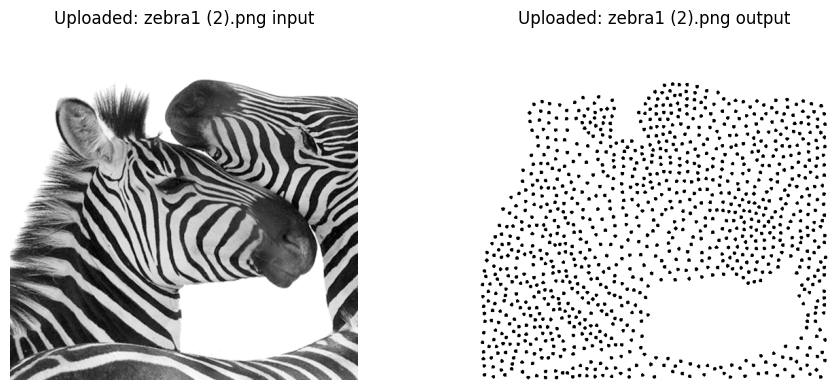

{'image_path': '/content/BNOT_new/python/notebooks/_generated_colab/uploaded_zebra1 (2)_input.pgm', 'output_path': '/content/BNOT_new/python/notebooks/_generated_colab/uploaded_zebra1 (2).eps', 'stats_path': '/content/BNOT_new/python/notebooks/_generated_colab/uploaded_zebra1 (2).txt', 'weight_solver': 'newton', 'seed': 7, 'render_width': 512, 'render_height': 512, 'point_radius': 0.004, 'visible_sites': 1024, 'iterations': 3, 'energy': -0.01058015021426408, 'mean_capacity': 0.09330035001039505, 'mean_abs_capacity_error': 2.855687026915758e-07, 'max_abs_capacity_error': 0.0001135113555530282, 'rms_abs_capacity_error': 4.766709399916803e-06, 'mean_rel_capacity_error': 3.060746317240601e-06, 'max_rel_capacity_error': 0.001216623040968027, 'rms_rel_capacity_error': 5.108994124229674e-05}


In [53]:
import io
from google.colab import files

print("Please select an image to upload:")
uploaded = files.upload()

if not uploaded:
    print("No file was uploaded.")
else:
    # Get the first uploaded file
    filename = list(uploaded.keys())[0]
    content = uploaded[filename]

    # Process the image content from memory
    uploaded_image = Image.open(io.BytesIO(content)).convert("L")
    uploaded_image = uploaded_image.resize((SIZE, SIZE))
    uploaded_array = np.asarray(uploaded_image, dtype=float) / 255.0

    # Run the BNOT solver
    uploaded_result = run_case(
        uploaded_array,
        OUTPUT_DIR,
        f"uploaded_{filename.split('.')[0]}",
        executable=CLI,
        num_sites=NUM_SITES,
        seed=SEED,
        render_width=OUTPUT_WIDTH,
        render_height=OUTPUT_HEIGHT,
        point_radius=POINT_RADIUS,
        invert=INVERT_DENSITY,
        dpi=DPI,
    )

    # Show the result
    show_case(f"Uploaded: {filename}", uploaded_array, uploaded_result)